Import Libraries

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from sklearn.model_selection import train_test_split

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)

Load Dataset into X and y

In [ ]:
np.random.seed(0)

X = np.vstack([

    np.random.randn(250, 2) * 0.5 + [-1, -1],

    np.random.randn(250, 2) * 0.5 + [-1,  1],

    np.random.randn(250, 2) * 0.5 + [ 1, -1],

    np.random.randn(250, 2) * 0.5 + [ 1,  1],

])
y = np.array([0]*250 + [1]*250 + [1]*250 + [0]*250)


df = pd.DataFrame(X, columns=['x1', 'x2'])
df['y'] = y

df

,x1,x2,y
0,-0.117974,-0.799921,0
1,-0.510631,0.120447,0
2,-0.066221,-1.488639,0
3,-0.524956,-1.075679,0
4,-1.051609,-0.794701,0
...,...,...,...
995,1.671311,0.630032,0
996,1.657569,0.838271,0
997,1.098914,1.048875,0
998,1.700762,1.079217,0


In [ ]:
df['y'].unique()

array([0, 1])

create a visual to display the linear decision boundary

/tmp/ipykernel_8860/2703245846.py:19: RuntimeWarning: divide by zero encountered in divide
  y_vals = -(w[0] * x_vals + b) / w[1]


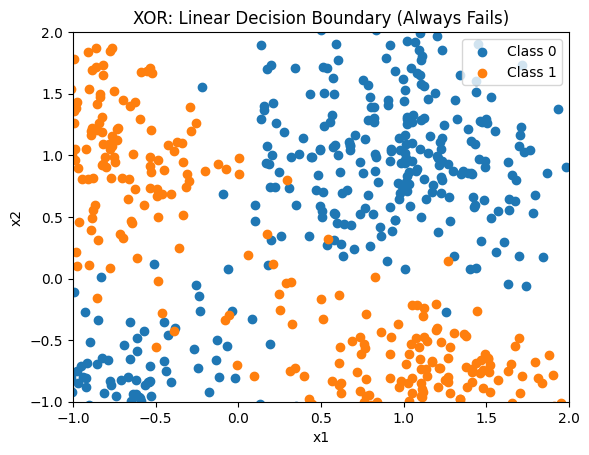

In [ ]:
fig, ax = plt.subplots()

for label in np.unique(y):
    ax.scatter(X[y == label, 0], X[y == label, 1], label=f"Class {label}")

ax.set_xlim(-1, 2)
ax.set_ylim(-1, 2)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.legend()

line, = ax.plot([], [])
x_vals = np.linspace(-1, 2, 200)

def update(frame):
    angle = frame * 0.1
    w = np.array([np.cos(angle), np.sin(angle)])
    b = 0.0
    y_vals = -(w[0] * x_vals + b) / w[1]
    line.set_data(x_vals, y_vals)
    ax.set_title("XOR: Linear Decision Boundary (Always Fails)")
    return line,

anim = FuncAnimation(fig, update, frames=100, interval=100)

HTML(anim.to_jshtml())

we create a function to plot boundary after prediction

In [ ]:
def plot_boundaries(X, y, y_hat):
    plt.figure(figsize=(8, 3))
    plt.subplot(1, 2, 1)

    for label in np.unique(y):
        plt.scatter(X[y == label, 0], X[y == label, 1], label=f"Class {label}")

    plt.xlim(-1, 2)
    plt.ylim(-1, 2)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.scatter(y, y)
    plt.scatter(y, y_hat)

we create a function to plot losses after training

In [ ]:
def plot_losses(plt, losses):
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")

we create another function to plot decision boundary and how the model sepearte the classes

In [ ]:
def plot_decision_boundary(model, X, y, device="cpu", resolution=200):
    """
    Plots the decision boundary of a trained PyTorch binary classifier.

    Args:
        model: Trained PyTorch model
        X: Input features (numpy array, shape [N, 2])
        y: Labels (numpy array, shape [N])
        device: 'cpu' or 'cuda'
        resolution: Grid resolution for the plot
    """
    model.eval()
    model.to(device)

    # Define grid limits
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution)
    )

    # Prepare grid points
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid, dtype=torch.float32).to(device)

    # Model prediction
    with torch.no_grad():
        preds = model(grid_tensor)
        preds = preds.squeeze().cpu().numpy()

    # Reshape predictions to grid
    Z = preds.reshape(xx.shape)

    # Plot contour and data points
    plt.figure(figsize=(5, 3))
    plt.contourf(xx, yy, Z > 0.5, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", cmap="coolwarm")

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Decision Boundary")
    plt.show()

first we create our simple feedforward nearal network

In [ ]:
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(2, 1)
        self.out_act = nn.Sigmoid()

    def forward(self, x):
        return self.out_act(self.fc(x))

then we create a 2 layer feed forward nearal network with an hidden layer

In [ ]:
class TwoLayerNetwork(nn.Module):
    def __init__(self):
        # Architecture of the network.
        super().__init__()
        self.input_layer = nn.Linear(2, 2)
        self.hidden_layer = nn.Linear(2, 4)
        self.act = nn.ReLU()
        self.output_layer = nn.Linear(4, 1)
        self.out_act = nn.Sigmoid()

    def forward(self, x):
        # Alternative implementation using Sequential
        # Forward propagation steps.
        # Step 1: pass the signal x through the input layer with no activation.
        # Step 2: pass the signal through the hidden layer.
        # Step 3: pass the signal through the activation function.
        # Step 4: pass the signal through the output layer.
        # Step 5: pass the signal through the output activation.

        stack = nn.Sequential(
            self.input_layer,
            self.hidden_layer,
            self.act,
            self.output_layer,
            self.out_act
        )
        return stack(x)

now we split our dataset into test and train dataset

In [ ]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)


print ("Training_Set:", X_train.shape)
print ("Test_Set:", X_test.shape)
print ("Y_train_Set:", y_train.shape)

Training_Set: (800, 2)
Test_Set: (200, 2)
Y_train_Set: (800,)


now we are to create a Training loop for the XorNetwork

In [ ]:
def xor_training_loop(model, X, y, optimizer=None, criterion=None, epochs=1000, lr=0.01):
    # Training loop for the XorNetwork.
    losses = []

    X_train = torch.from_numpy(X).float()
    y_train = torch.from_numpy(y).float().reshape(-1, 1)

    if optimizer is None:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    if criterion is None:
        criterion = nn.BCELoss()

    for epoch in range(epochs):
        y_hat = model(X_train).view(-1, 1)

        # Zero_grad - clear previous gradients calculated by the autograd
        optimizer.zero_grad()

        # Do backward calculation of gradients.
        # gradient = X * (y_pred - y) * g'(x)
        loss = criterion(y_hat, y_train)
        losses.append(loss.item())
        loss.backward()

        # Update the parameters using the specified optimizer.
        # dm = dm - lr * gradient
        optimizer.step()

        if epoch % 100 == 0:
          print(f"Epoch {epoch}: Loss {loss.item()}")


    return model, losses

first we run our simple network on our train dataset

Epoch 0: Loss 0.7218589186668396
Epoch 100: Loss 0.6930032968521118
Epoch 200: Loss 0.6928821802139282
Epoch 300: Loss 0.6928815245628357
Epoch 400: Loss 0.6928815245628357
Epoch 500: Loss 0.6928815245628357
Epoch 600: Loss 0.6928815245628357
Epoch 700: Loss 0.6928814649581909
Epoch 800: Loss 0.6928814649581909
Epoch 900: Loss 0.6928814649581909


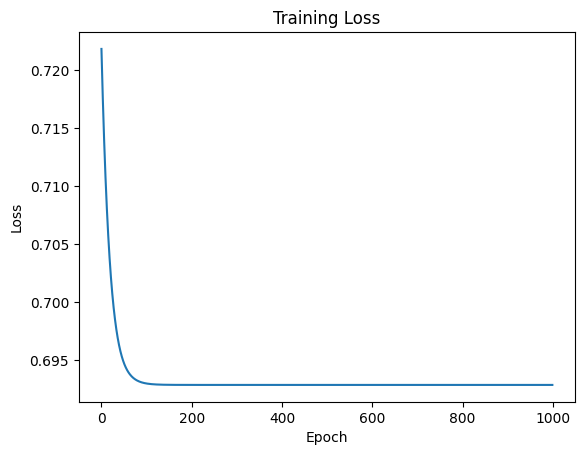

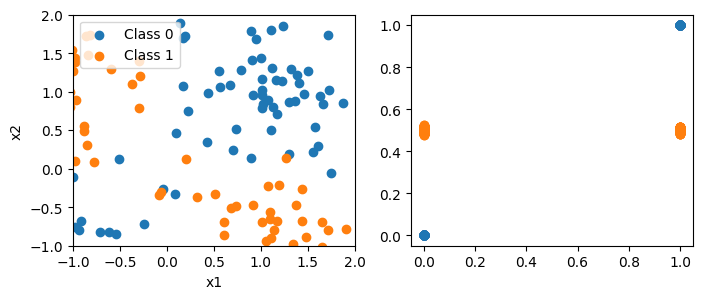

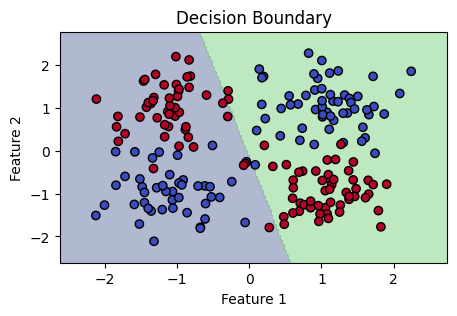

In [ ]:
model = SimpleNet()

model, S_losses = xor_training_loop(
    model, X_train, y_train,
    epochs=1000,
    criterion=nn.BCELoss(),
    # optimizer=torch.optim.Adam(model.parameters(), lr=0.01),
    lr=0.1
)

y_hat = model(torch.from_numpy(X_test).float()).detach().numpy()
# Convert probabilities to classes
y_pred = (y_hat >= 0.5).astype(int)

plot_losses(plt, S_losses)
plot_boundaries(X_test, y_test, y_hat)
plot_decision_boundary(model, X_test, y_test)

lets check the performance of our model on the 0 layer network

In [ ]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.4850
Precision: 0.4862
Recall   : 0.5300
F1 Score : 0.5072

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.44      0.46       100
           1       0.49      0.53      0.51       100

    accuracy                           0.48       200
   macro avg       0.48      0.48      0.48       200
weighted avg       0.48      0.48      0.48       200


Confusion Matrix:
[[44 56]
 [47 53]]


we run a training with our 2 layer network

Epoch 0: Loss 0.6891694664955139
Epoch 100: Loss 0.5497581362724304
Epoch 200: Loss 0.3654954433441162
Epoch 300: Loss 0.2959677577018738
Epoch 400: Loss 0.26875022053718567
Epoch 500: Loss 0.2568322420120239
Epoch 600: Loss 0.2513081729412079
Epoch 700: Loss 0.2485245168209076
Epoch 800: Loss 0.2469930797815323
Epoch 900: Loss 0.24608848989009857


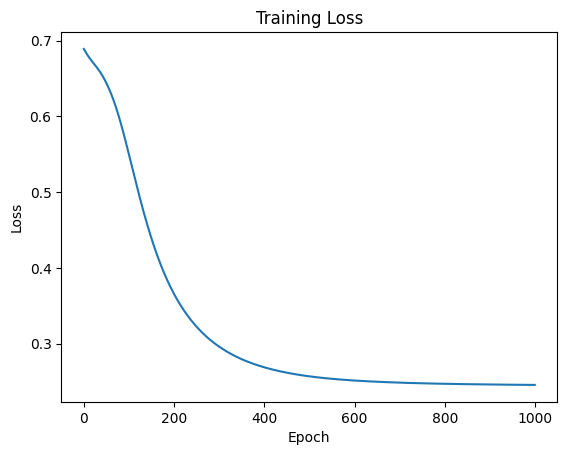

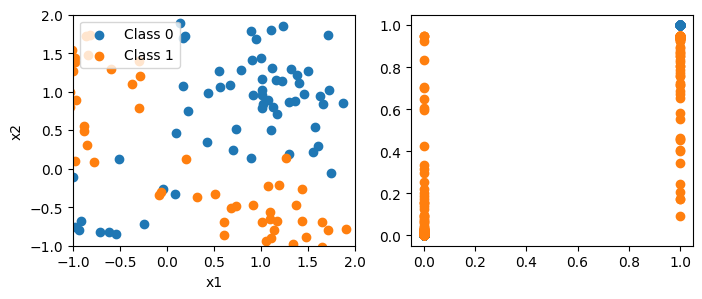

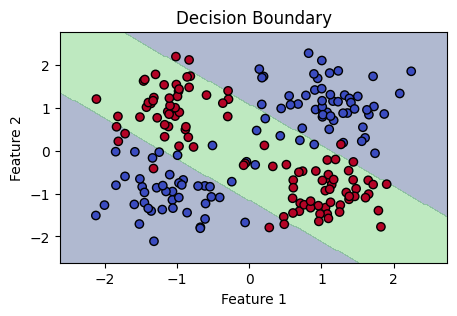

In [ ]:
model = TwoLayerNetwork()

model, T_losses = xor_training_loop(
    model, X_train, y_train,
    epochs=1000,
    criterion=nn.BCELoss(),
    # optimizer=torch.optim.Adam(model.parameters(), lr=0.01),
    lr=0.1
)

y_hat = model(torch.from_numpy(X_test).float()).detach().numpy()
# Convert probabilities to classes
y_pred = (y_hat >= 0.5).astype(int)

plot_losses(plt, T_losses)
plot_boundaries(X_test, y_test, y_hat)
plot_decision_boundary(model, X_test, y_test)

lets check the performance of our model on the 2 layer network

In [ ]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.8950
Precision: 0.8990
Recall   : 0.8900
F1 Score : 0.8945

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.90       100
           1       0.90      0.89      0.89       100

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.89       200
weighted avg       0.90      0.90      0.89       200


Confusion Matrix:
[[90 10]
 [11 89]]


The simple neural network (no hidden layer) performed poorly because it could only learn a linear decision boundary. Since the data is arranged in multiple clusters, a single straight line was not enough to separate the classes effectively.

The two-layer neural network performed much better
 because the hidden layer allowed it to learn non-linear patterns in the data. This resulted in a decision boundary that closely matched the structure of the clusters, leading to very few classification errors.

Key takeaway: Adding a hidden layer significantly improved performance because the dataset is not linearly separable. The hidden layer enabled the network to capture the complex relationships that the simple network could not.

lets us visualize the losses for oue 2 netowrks

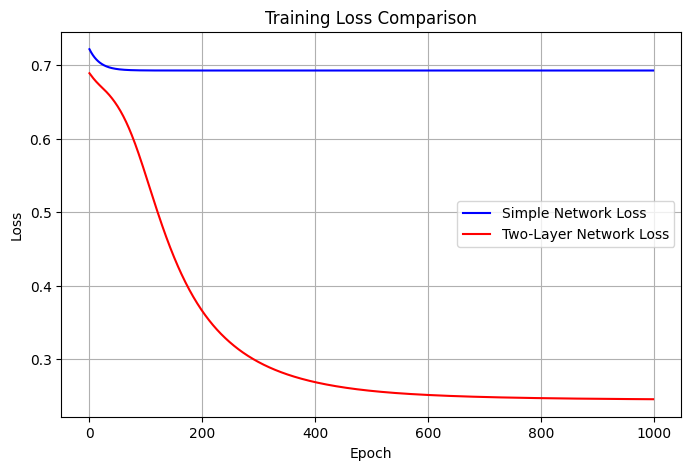

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(S_losses, label='Simple Network Loss', color='blue')
plt.plot(T_losses, label='Two-Layer Network Loss', color='red')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True)

plt.show()